# Exercise 3: Fitting

## Analysis of Exponential Decay Data

You are given a dataset representing exponential decay with added noise. The fraction of remaining particles follows the equation:  


$$y = e^{t/\tau}$$


where:  
- $ \tau $ is the decay constant,  
- $ t $ represents time,  
- measurement uncertainty is estimated to be $ \sigma = 0.1 $ for all times.  

**Tasks**  

**1. Compute the Chi-Squared Statistic**  
- Evaluate $ \chi^2 $ for $ \tau $ values between 1 and 2.  
- Identify the best-fit $ \tau $ by finding the minimum $ \chi^2 $.  

**2. Estimate Uncertainty**  
- Use the $ \Delta \chi^2 $ method to determine the confidence interval for $ \tau $.  

**3. Visualize the Data and Best Fit**  
- Plot the given data with error bars.  
- Overlay the best-fit exponential decay curve.  

**4. Graphical Representation of $ \chi^2 $**  
- Plot $ \chi^2 $ as a function of $ \tau $.  
- Highlight the $ 1\sigma $ confidence regions based on $ \Delta \chi^2 $.  

**5. Goodness of fit**
- Looking at the mimimum $\chi^2$, do you think the uncertainty estimation is realistic?

In [1]:
import numpy as np
t, data = np.loadtxt("data_ex1.txt", unpack=True) #here data refers to the fraction of remaining particles (according to the description of the exercise)
data_errors = np.full_like(data, 0.1)
data_var = data_errors ** 2

In the lecture, we learned how to compute the best estimate of a parameter analytically in the case of a linear function. Now, compute the best estimate for $\tau$, including the uncertainty, in a similar way. 

Do you get "compatible" results ?

**Hint**: You may want to use a coordinate transformation.

In [2]:
# 1.
def compute_chisquared(x,y,var_y,model,**dict_args):
    """Computes the chi-squared of the set of data
    
    The function needs the data as inputs, the variance of the y data and the function of the distribution to
    which the data belongs. It returns the not-normalized chi-squared. Additionally you can give more inputs:
    - model_param: the collection of parameters needed by the function  model, passed as an iterable object if
                   the model needs more than one parameter
    - var_x:       the variance of the x coordinates"""
    import numpy as np

    # Checking basic input sizes
    if (len(x) != len(y)) or (len(x) != len(var_y)):
        print("Inputs to compute_chisquared have different lengths. Aborting")
        raise ValueError("Stopping execution due to invalid input size.")
    N = len(x)

    # Managing variances
    var = np.zeros(N)
    i = 0
    try: #try if there are variances of the x coordinates
        if len(x) != len(dict_args['var_x']):
            print("Inputs to compute_chisquared have different lengths. Aborting")
            raise ValueError("Stopping execution due to invalid input size.")
        from scipy.optimize import approx_fprime
        try: #try with parameters for the model
            while i < N:
                var[i] = dict_args['var_x'][i]*(approx_fprime(x[i],model,1e-8,dict_args['model_param'])[0])**2 + var_y[i] #note that approx_fprime returns an array: in our case it is simply made of a single number, so I select the first and only entry to avoid errors
                i += 1
        except KeyError: #no parameters for the model
            try: #try without parameters for the model
                while i < N:
                    var[i] = dict_args['var_x'][i]*(approx_fprime(x[i],model,1e-8)[0])**2 + var_y[i] #note that approx_fprime returns an array: in our case it is simply made of a single number, so I select the first and only entry to avoid errors
                    i += 1
            except IndexError: #no parameters but the model needs them
                print("compute_chisquared: no model_parameter detected but the model requires them. Aborting")
                raise
        except TypeError: #the model doesn't want additional parameters
            print("compute_chisquared: model_parameter detected but the model doesn't require them. Aborting")
            raise
        #print("compute_chisquared: var_x detected!")
    except KeyError: #no variances of the x coordinates
        while i < N:
            var[i] = var_y[i]
            i += 1
        #print("compute_chisquared: no var_x detected!")

    # Computing chi-squared
    chi_squared = 0
    i = 0
    try: #try with parameters for the model
        while i < N:
            chi_squared += (model(x[i],dict_args['model_param']) - y[i])**2/var[i]
            i += 1
        #print("compute_chisquared: model_param detected!")
    except KeyError: #no parameters for the model
        try: #try without parameters for the model
            while i < N:
                chi_squared += (model(x[i]) - y[i])**2/var[i]
                i += 1
        except IndexError: #no parameters but the model needs them
            print("compute_chisquared: no model_parameter detected but the model requires them. Aborting")
            raise
        #print("compute_chisquared: no model_param detected!")
    except TypeError: #the model doesn't want additional parameters
            print("compute_chisquared: model_parameter detected but the model doesn't require them. Aborting")
            raise

    # Returning the final outcome
    return chi_squared
    

In [3]:
def exp_decay(t,*tau):
    import math as m

    try:
        tau[1]
        print("exp_decay: too many input parameters. Aborting")
        raise ValueError("Stopping execution due to an excess number of parameters.")
    except IndexError:
        try:
            tau[0][1] #tau is a tuple of given inputs. When compute_chisquared calls this function, the parameters are stored in the first
                      #entry of the tuple. In this case it's only a single number, in case of multiple parameters, the first entry is a
                      #tuple or a list itself
            print("exp_decay: too many input parameters. Aborting")
            raise ValueError("Stopping execution due to an excess number of parameters.")
        except IndexError:
            return m.exp(-t/tau[0]) #taking the first and only entry
        except TypeError:
            return m.exp(-t/tau[0]) #taking the first and only entry

In [4]:
import numpy as np

tau_values = np.linspace(0.1,20,int(1e4))
chi_squared_values = []
for tau in tau_values:
    chi_squared_values.append(compute_chisquared(t, data, data_var, exp_decay, model_param=tau))
chi_squared_values = np.array(chi_squared_values)

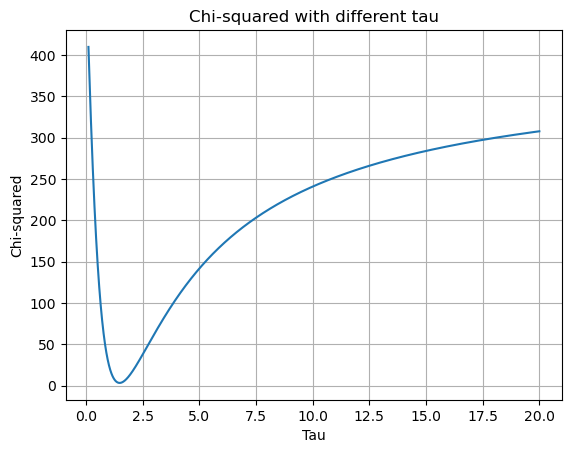

In [5]:
import matplotlib.pyplot as plt

plt.plot(tau_values, chi_squared_values)
plt.grid(1)
plt.title('Chi-squared with different tau')
plt.xlabel('Tau')
plt.ylabel('Chi-squared')
plt.show()

In [6]:
# Since we can see from the graph that there's a minimum between 0.5 and 2.5, I'll look for it there
tau_values = np.linspace(0.5,2.5,int(1e5))
chi_squared_values = []
for tau in tau_values:
    chi_squared_values.append(compute_chisquared(t, data, data_var, exp_decay, model_param=tau))
chi_squared_values = np.array(chi_squared_values)

index = np.argmin(chi_squared_values)
best_tau = tau_values[index]
best_chi = chi_squared_values[index]
print(f"The optimal value for tau is {best_tau}, corresponding to a chi value of {best_chi}")

The optimal value for tau is 1.476029760297603, corresponding to a chi value of 3.422776975486686


In [7]:
# 2.
# For a single parameter to be estimated the \Delta\chi^2 corresponding to 68% of confidence region (1 sigma of the parameter)
# is simply 1. So we need to find which values of tau produce best_chi+1
tau_within_1sigma = []
i = 0
while i < len(chi_squared_values): #looking for the first value>best_tau that crosses the bound chi^2+1
    i += 1
    if chi_squared_values[index+i]<best_chi+1:
        tau_within_1sigma.append(tau_values[index+i])
    else:
        break
i = 0
while i < len(chi_squared_values): #looking for the first value>best_tau that crosses the bound chi^2+1
    i += 1
    if chi_squared_values[index-i]<best_chi+1:
        tau_within_1sigma.append(tau_values[index-i])
    else:
        break
        
best_tau_error = max( max(tau_within_1sigma)-best_tau, best_tau - min(tau_within_1sigma) )
print(f"The optimal value for tau is {best_tau} pm {best_tau_error}, corresponding to a chi value of {best_chi}")

The optimal value for tau is 1.476029760297603 pm 0.12996129961299618, corresponding to a chi value of 3.422776975486686


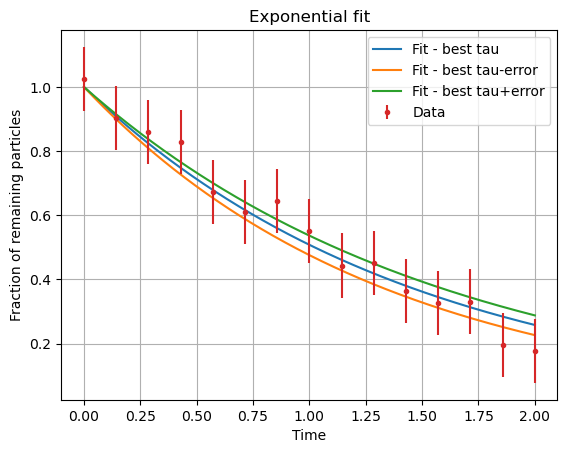

In [8]:
# 3.
import matplotlib.pyplot as plt

x = np.linspace(min(t),max(t),int(1e4))
y = []
for point in x:
    y.append(exp_decay(point,best_tau))
y = np.array(y)
plt.plot(x,y,label='Fit - best tau')

y = []
for point in x:
    y.append(exp_decay(point,best_tau-best_tau_error))
y = np.array(y)
plt.plot(x,y,label='Fit - best tau-error')

y = []
for point in x:
    y.append(exp_decay(point,best_tau+best_tau_error))
y = np.array(y)
plt.plot(x,y,label='Fit - best tau+error')

plt.errorbar(t,data,data_errors, fmt='.', label='Data')
plt.grid(1)
plt.legend()
plt.title('Exponential fit')
plt.xlabel('Time')
plt.ylabel('Fraction of remaining particles')
plt.show()

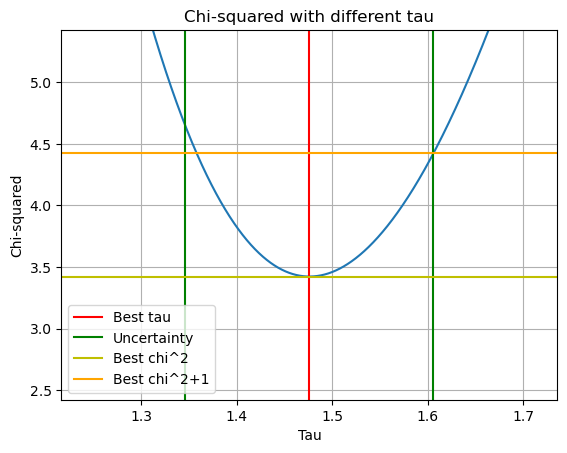

It's alright if one green line is further than the crossing point with chi^2+1 because we are being conservative on the error


In [9]:
# 4.
plt.plot(tau_values, chi_squared_values)
plt.grid(1)
plt.title('Chi-squared with different tau')
plt.xlabel('Tau')
plt.ylabel('Chi-squared')
plt.axvline(x=best_tau,label='Best tau', color='r')
plt.axvline(x=best_tau-best_tau_error,label='Uncertainty', color='g')
plt.axvline(x=best_tau+best_tau_error, color='g')
plt.axhline(y=best_chi, label='Best chi^2', color='y')
plt.axhline(y=best_chi+1, label='Best chi^2+1', color='orange')
plt.legend()
plt.xlim((best_tau-2*best_tau_error, best_tau+2*best_tau_error))
plt.ylim((best_chi-1,best_chi+2))
plt.show()
print("It's alright if one green line is further than the crossing point with chi^2+1 because we are being conservative on the error")

In [10]:
# 5.
# The value of the minimum reduced chi-squared is
chi_squared_values[index]/(len(t)-1)
# which is quite below one. The p-value corresponding to this chi-squared is
from scipy.stats import chi2
1-chi2.cdf(chi_squared_values[index],len(t)-1)
#which is super high

np.float64(0.9980541645972586)

In [11]:
# 6.
# We can rewrite log(data) = -t/tau and estimate tau as the opposite of the inverse of the coefficient of a linear fit between t
# (as x coordinates) and log(data) (as y coordinates). Also, the straight line shall pass through the origin.
m = np.average(t*np.log(data)) / np.average(t**2)
var_m = data_var[0]/len(t)/np.average(t**2)

analytical_best_tau = -1/m
var_analytical_best_tau = 1/m**4*var_m
print(f"Analytical value for the best tau: {analytical_best_tau}+/-{np.sqrt(var_analytical_best_tau)}")
# I am still missing the uncertainty on tau estimated by minimizing the chi-squared.

Analytical value for the best tau: 1.358709810389081+/-0.040561914124827944


## Polynomial Fit with Parameter Uncertainty

You are given data that was generated using a polynomial of degree 5. Therefore, you have 6 free parameters (the 6 coefficients). Your task is to perform a fit to obtain these parameters and their covariances.

**Steps:**
1. Fit a polynomial to the data and determine the parameters.
2. Calculate the uncertainties for each parameter.
3. **Bonus**: Instead of just showing the 1D uncertainties for each parameter, visualize the correlations between these uncertainties.

You can use an optimizer from `scipy` to perform the fit and "TriangleChain" for the last point.

In [12]:
x, data = np.loadtxt("data_ex2.txt", unpack=True)
data_var = np.ones(len(x)) #errors are needed to compute the chi-squared, so I set them all equal to one, so that all
                           #points have the same weight. Note that the actual value of chi-squared will have no meaning
                           #but we can still use the delta-chi-squared method to compute uncertainties

In [13]:
def poly5(x, *param):
    '''Polynomial of order 5

    The function needs the six parameters of a0 + a1*x + a2*x**2 + a3*x**3 + a4*x**4 + a5*x**5, all stored in
    a single iterable object passed'''

    return param[0][0] + param[0][1]*x + param[0][2]*x**2 + param[0][3]*x**3 + param[0][4]*x**4 + param[0][5]*x**5

In [14]:
def prepared_chi_squared(param, **data_dict):
    '''This function evaluates the chi-squared for a given set of parameters, now seen as the main input of the
    function. This is needed beacuse the minimizing functions can minimize the main input, not the parameters.
    The function additionally requires the inputs
    - x the x data to be fitted
    - y the y data to be fitted
    - var_y the variance on the second coordinate (required)
    - var_x the variance on the first coordinate (optional)
    - model the function to be fitted'''
    
    if 'var_x' in data_dict:
        chi_squared = compute_chisquared(data_dict['x'], data_dict['y'], data_dict['var_y'], data_dict['model'], model_param=param, var_x=data_dict['var_x'])
    else:
        chi_squared = compute_chisquared(data_dict['x'], data_dict['y'], data_dict['var_y'], data_dict['model'], model_param=param)
    
    return chi_squared

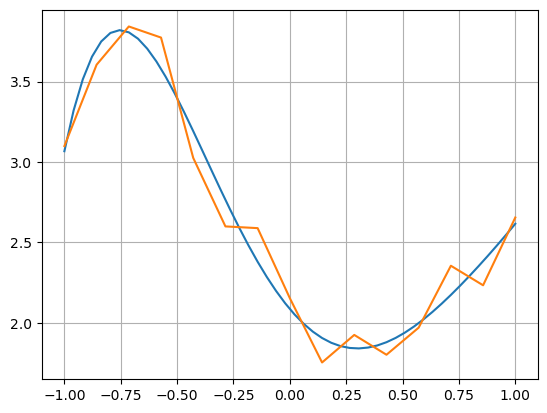

In [23]:
from scipy.optimize import minimize

initial_param = np.zeros(6)
optimization_results = minimize(lambda param: compute_chisquared(x, data, data_var, poly5, model_param=param), initial_param, method='BFGS')
best_param = optimization_results.x
best_param_cov_matrix = optimization_results.hess_inv*2

points = np.linspace(min(x),max(x))
y = []
for point in points:
    y.append(poly5(point, best_param))
plt.plot(points,y)
plt.plot(x,data)
plt.grid(1)
plt.show()

(6,)
(6, 6)


  0%|          | 0/15 [00:00<?, ?it/s]

(<Figure size 2400x2400 with 36 Axes>,
 array([[<Axes: ylabel='0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='2'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='3'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='4'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: xlabel='0', ylabel='5'>, <Axes: xlabel='1'>,
         <Axes: xlabel='2'>, <Axes: xlabel='3'>, <Axes: xlabel='4'>,
         <Axes: xlabel='5'>]], dtype=object))

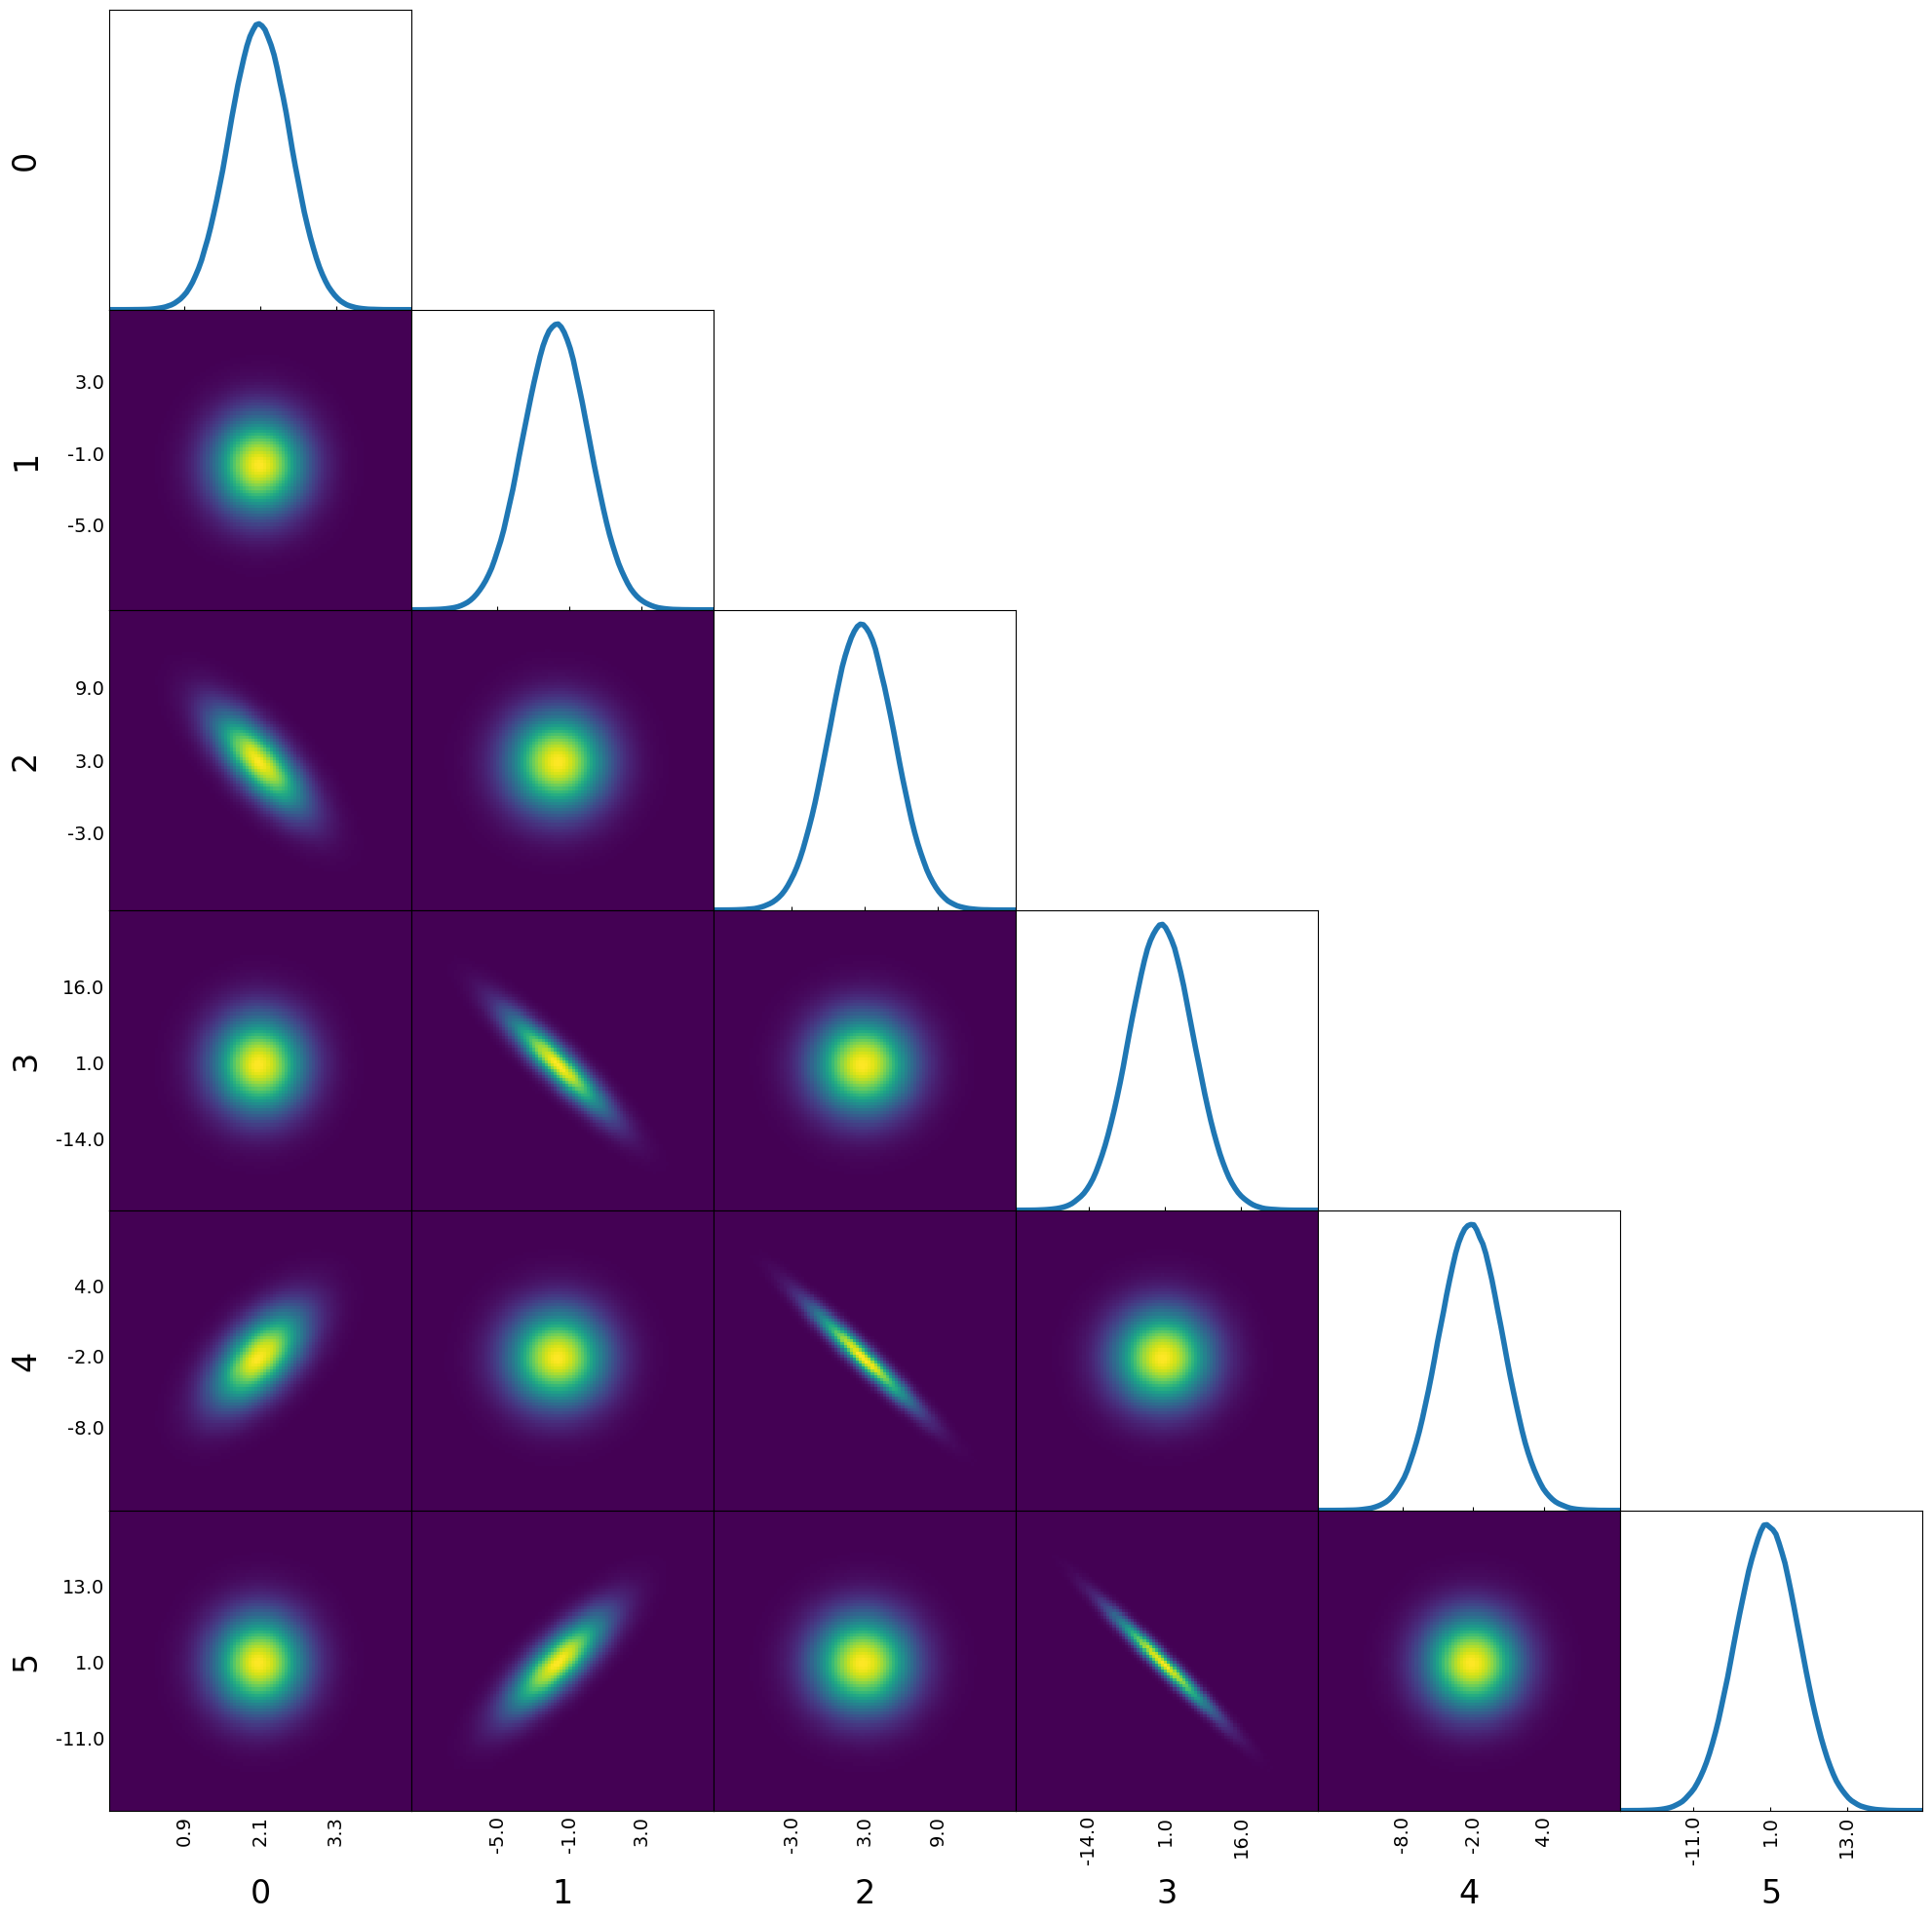

In [24]:
# 3. 
from trianglechain import TriangleChain as tri

print(np.shape(best_param))
print(np.shape(best_param_cov_matrix))
samples = np.random.multivariate_normal(best_param, best_param_cov_matrix, size=int(1e6))
tri().density_image(samples)

## Goodness of fit

You are given datasets $x$ and $y$ that follow a polynomial relationship, with the uncertainty in $y$ equal to 5. Fit both a first-degree (linear) and a second-degree (quadratic) polynomial to the data. Compute the reduced chi-squared and the p-value for each model. Determine which model provides a better fit based on these statistical measures.

What would happen to the p value if you further increase the degrees of the polynomial?

In [25]:
x, y = np.loadtxt("data_ex3.txt", unpack=True)
y_err = np.ones_like(y) * 5

In [26]:
def poly1(x,*param):
    return param[0][0]*x + param[0][1]

def poly2(x,*param):
    return param[0][0]*x**2 + param[0][1]*x + param[0][2]

def poly3(x,*param):
    return param[0][0]*x**3 + param[0][1]*x**2 + param[0][2]*x + param[0][3]

def poly4(x,*param):
    return param[0][0]*x**4 + param[0][1]*x**33 + param[0][2]*x**2 + param[0][3]*x + param[0][4]

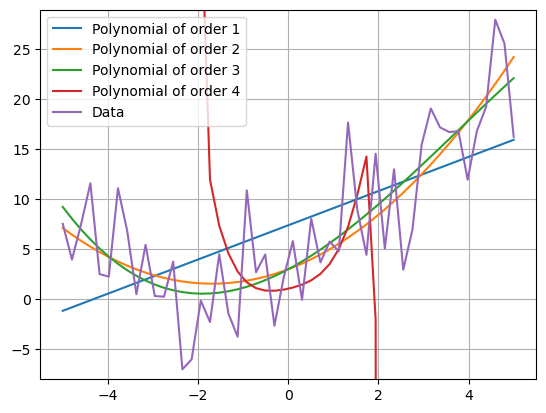

In [27]:
from scipy.optimize import minimize

models = [poly1, poly2, poly3, poly4]
i = 0
optimization_results = []
for fun in models:
    initial_param = np.ones(i+2)
    optimization_results.append( minimize(lambda param: compute_chisquared(x, y, y_err**2, fun, model_param=param), initial_param, method='BFGS') )

    abscissa = np.linspace(min(x),max(x))
    ordinate = []
    for point in abscissa:
        ordinate.append(fun(point, optimization_results[i].x))
    plt.plot(abscissa,ordinate, label=f"Polynomial of order {i+1}")
    plt.grid(1)
    
    i += 1

plt.plot(x,y, label="Data")
plt.ylim((min(y)-1, max(y)+1))
plt.legend()
plt.show()

In [28]:
from scipy.stats import chi2

best_chi_values = []
best_reduced_chi_values = []
p_values = []
for result in optimization_results:
    best_chi_values.append(result.fun)
    p_values.append( 1-chi2.cdf(best_chi_values[-1], len(x)-len(result.x)) )
    best_reduced_chi_values.append( best_chi_values[-1]/(len(x)-len(result.x)) )
    print(f"Polynomial of order {len(result.x)-1}".ljust(25), f"Lowest reduced chi-squared: {str(best_reduced_chi_values[-1]).ljust(25)} Corresponding p-value: {str(p_values[-1]).ljust(15)}")

Polynomial of order 1     Lowest reduced chi-squared: 1.4748157552953653        Corresponding p-value: 0.017827558537677923
Polynomial of order 2     Lowest reduced chi-squared: 0.8484819232485349        Corresponding p-value: 0.7597628792323916
Polynomial of order 3     Lowest reduced chi-squared: 0.8318391860891544        Corresponding p-value: 0.7840973671521232
Polynomial of order 4     Lowest reduced chi-squared: 1.4280154318251534e+27    Corresponding p-value: 0.0            


## Gradient descent
Minimize the function:

$$
f(x, y) = x^2 + (y - 1)^2 + 0.1 \cdot x^4 + 0.1 \cdot y^4
$$

1. **Compute the Gradient**  
   Find the partial derivatives of the function with respect to $x$ and $y$.

2. **Implement Gradient Descent**  
   Update the parameters using:
   $$
   x_{\text{new}} = x_{\text{old}} - \alpha \cdot \frac{\partial f}{\partial x}, \quad y_{\text{new}} = y_{\text{old}} - \alpha \cdot \frac{\partial f}{\partial y}
   $$

3. **Plot the Path to the Minimum**  
   Run gradient descent with different starting points and learning rates. Plot the optimization path to the minimum for the different scenarios and plot how the step size evolves.

4. **Different function**
    Change the initial function (e.g. change $x^2$ to $x^3$) and redo Steps 1-3. Do you have to adapt the learning rate?

In [29]:
# 1.
def compute_grad_f(coordinates):
    x,y = coordinates
    df_dx = 2*x + 0.4*x**3
    df_dy = 2*(y-1) + 0.4*y**3
    return (df_dx,df_dy)

In [30]:
# 2.
def compute_distance(coordinates1, coordinates2):
    x1, y1 = coordinates1
    x2, y2 = coordinates2
    return ( (x1-x2)**2 + (y1-y2)**2 )**0.5

In [31]:
def grad_descent(compute_grad, initial_param, step, epsilon, **kwarg):
    '''Function implementing gradient descent

    It requires a function evaluating the gradient of the function to be minized, a starting point, the step length
    that tells how to update the points and the precision (epsilon) we are satisfied to achieve.
    Optionally, the user can input an empty list called track that will contain all the middle points touched before
    reaching the minimum.'''
    
    df_dx, df_dy = compute_grad(initial_param)
    new_param = (initial_param[0] - step*df_dx, initial_param[1] - step*df_dy)
    


    if compute_distance(new_param,initial_param) > epsilon:
        if 'track' in kwarg:
            kwarg['track'].append(new_param)
            return grad_descent(compute_grad, new_param, step, epsilon, track=kwarg['track'])
        else: 
            return grad_descent(compute_grad, new_param, step, epsilon)
    else:
        return new_param

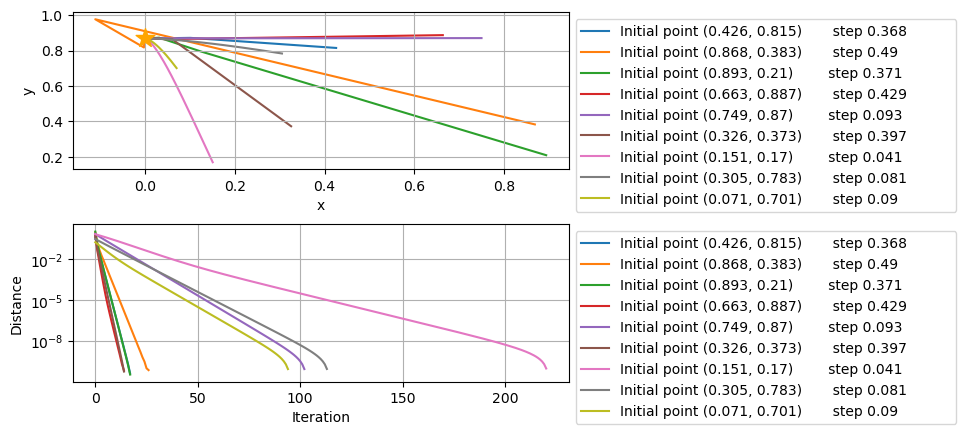

In [32]:
# 3.
import matplotlib.pyplot as plt
np.random.seed(27)

starting_points = []
steps = []
for i in range(1,10):
    starting_points.append( (np.random.uniform(0,1), np.random.uniform(0,1)) )
    steps.append( np.random.uniform(0,0.5) )
epsilon = 1e-10

tracks = []
distances = []
for starting_point in starting_points:
    index = starting_points.index(starting_point)
    step = steps[index]
    track = [starting_point]
    final_point = grad_descent(compute_grad_f, starting_point, step, epsilon, track=track)
    track = np.array(track)
    tracks.append(track)
    
    distance = []
    for point in track:
        distance.append(compute_distance(point, final_point))
    distances.append( np.array(distance) )
    
    plt.subplot(2,1,1)
    plt.plot(track[:, 0], track[:,1], zorder=1, label = f'Initial point {tuple(round(coordinate,3) for coordinate in starting_point)}'.ljust(35)+f'step {round(step,3)}'.ljust(20))
    
    
    plt.subplot(2,1,2)
    plt.plot(distance, label = f'Initial point {tuple(round(coordinate,3) for coordinate in starting_point)}'.ljust(35)+f'step {round(step,3)}'.ljust(20))


plt.subplot(2,1,1)
plt.scatter(final_point[0], final_point[1],marker='*', s=200, color='orange', zorder=2)
plt.grid(1)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('x')
plt.ylabel('y')

plt.subplots_adjust(hspace = 0.35)

plt.subplot(2,1,2)
plt.yscale('log')
plt.grid(1)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Iteration')
plt.ylabel('Distance')
plt.show()

In [33]:
# 4.
def compute_grad_g(coordinates):
    x,y = coordinates
    df_dx = 3*x**2 + 0.4*x**3
    df_dy = 2*(y-1) + 0.4*y**3
    return (df_dx,df_dy)

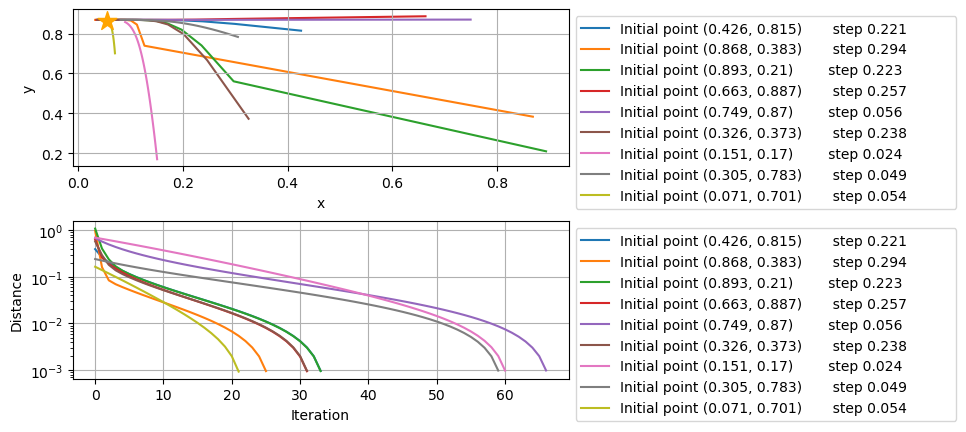

In [34]:
# 3.
import matplotlib.pyplot as plt
np.random.seed(27)

starting_points = []
steps = []
for i in range(1,10):
    starting_points.append( (np.random.uniform(0,1), np.random.uniform(0,1)) )
    steps.append( np.random.uniform(0,0.3) )
epsilon = 1e-3

tracks = []
distances = []
for starting_point in starting_points:
    index = starting_points.index(starting_point)
    step = steps[index]
    track = [starting_point]
    final_point = grad_descent(compute_grad_g, starting_point, step, epsilon, track=track)
    track = np.array(track)
    tracks.append(track)
    
    distance = []
    for point in track:
        distance.append(compute_distance(point, final_point))
    distances.append( np.array(distance) )
    
    plt.subplot(2,1,1)
    plt.plot(track[:, 0], track[:,1], zorder=1, label = f'Initial point {tuple(round(coordinate,3) for coordinate in starting_point)}'.ljust(35)+f'step {round(step,3)}'.ljust(20))
    
    
    plt.subplot(2,1,2)
    plt.plot(distance, label = f'Initial point {tuple(round(coordinate,3) for coordinate in starting_point)}'.ljust(35)+f'step {round(step,3)}'.ljust(20))


plt.subplot(2,1,1)
plt.scatter(final_point[0], final_point[1],marker='*', s=200, color='orange', zorder=2)
plt.grid(1)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('x')
plt.ylabel('y')

plt.subplots_adjust(hspace = 0.35)

plt.subplot(2,1,2)
plt.yscale('log')
plt.grid(1)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Iteration')
plt.ylabel('Distance')
plt.show()

In [35]:
# It is necessary to decresase the learning rate to avoid missing the minimum